In [1]:
%load_ext autoreload
%autoreload 2

from datasets import load_dataset
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
 
dataset = load_dataset("pubmed_qa", "pqa_labeled")

print(dataset)

print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

In [3]:
def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [4]:
def build_input(example):
    example["input_text"] = example["question"] + " " + example["combined_context"]
    return example

dataset = dataset.map(build_input)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
print(dataset['train'][0]['input_text'])

Do mitochondria play a role in remodelling lace plant leaves during programmed cell death? Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in late stages of PCD (L

In [6]:

l= [len(text.split()) for text in dataset['train']['input_text']]


print("Max length:", np.max(l))
print("Mean length:", np.mean(l))
print("Median length:", np.median(l))

Max length: 412
Mean length: 213.12
Median length: 213.5


(array([  9.,  38., 127., 203., 315., 186.,  78.,  26.,  11.,   7.]),
 array([ 58. ,  93.4, 128.8, 164.2, 199.6, 235. , 270.4, 305.8, 341.2,
        376.6, 412. ]),
 <BarContainer object of 10 artists>)

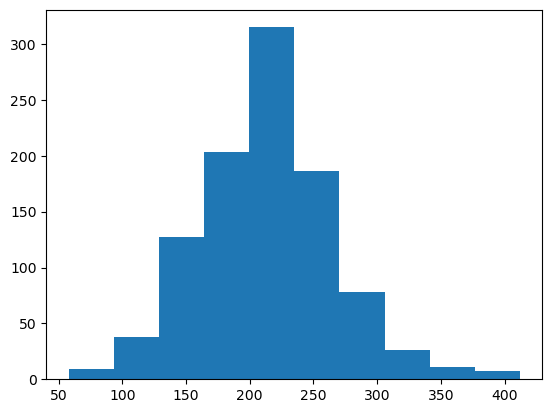

In [7]:
plt.hist(l)

In [8]:

df = dataset["train"].to_pandas()

In [9]:
X= df['input_text']
y= df['final_decision']
X_train, X_temp, Y_train, Y_temp = train_test_split(X,
                                                    y, 
                                                    test_size = 0.3, 
                                                    stratify = y, 
                                                    random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp,
                                                    Y_temp, 
                                                    test_size = 0.5, 
                                                    stratify = Y_temp, 
                                                    random_state=42)

print(len(X_train))
print(len(X_val))
print(len(X_test))

700
150
150


In [10]:
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)
Y_val_encoded = label_encoder.transform(Y_val)
num_classes = len(label_encoder.classes_)

print(f"Classes: {label_encoder.classes_}")

Classes: ['maybe' 'no' 'yes']


In [11]:
from gensim.utils import tokenize

X_train_tokens = [list(tokenize(text)) for text in X_train]
X_val_tokens = [list(tokenize(text)) for text in X_val]
X_test_tokens = [list(tokenize(text)) for text in X_test]

In [12]:
print(X_train_tokens[0])

['Telemedicine', 'and', 'type', 'diabetes', 'is', 'technology', 'per', 'se', 'sufficient', 'to', 'improve', 'glycaemic', 'control', 'Each', 'patient', 'received', 'a', 'smartphone', 'with', 'an', 'insulin', 'dose', 'advisor', 'IDA', 'and', 'with', 'G', 'group', 'or', 'without', 'G', 'group', 'the', 'telemonitoring', 'teleconsultation', 'function', 'Patients', 'were', 'classified', 'as', 'high', 'users', 'if', 'the', 'proportion', 'of', 'informed', 'meals', 'using', 'the', 'IDA', 'exceeded', 'median', 'and', 'as', 'low', 'users', 'if', 'not', 'Also', 'analyzed', 'was', 'the', 'respective', 'impact', 'of', 'the', 'IDA', 'function', 'and', 'teleconsultations', 'on', 'the', 'final', 'HbA', 'c', 'levels', 'Among', 'the', 'high', 'users', 'the', 'proportion', 'of', 'informed', 'meals', 'remained', 'stable', 'from', 'baseline', 'to', 'the', 'end', 'of', 'the', 'study', 'months', 'later', 'from', 'to', 'P', 'but', 'decreased', 'in', 'the', 'low', 'users', 'from', 'to', 'P', 'As', 'expected', '

In [13]:
from collections import Counter
counter = Counter()
for tokens in X_train_tokens:
    counter.update(tokens)

In [14]:
MAX_WORDS = 20000
mc = counter.most_common(MAX_WORDS - 2)
word2idx = {
    "<PAD>": 0,
    "<OOV>": 1
}

for i, (word, _) in enumerate(mc, start =2):
    word2idx[word] = i

In [15]:
def encode(tokens):
    return [word2idx.get(word,1 ) for word in tokens ] 

In [16]:
X_train_encoded = [encode(tokens) for tokens in X_train_tokens]
X_val_encoded = [encode(tokens) for tokens in X_val_tokens]
X_test_encoded = [encode(tokens) for tokens in X_test_tokens]

In [17]:
print(X_train_encoded[0])

[7645, 4, 155, 229, 21, 2492, 176, 5663, 2808, 6, 464, 7646, 81, 2241, 77, 173, 9, 7647, 7, 27, 500, 200, 7648, 4578, 4, 7, 773, 22, 14, 115, 773, 22, 3, 5664, 4579, 291, 152, 8, 807, 23, 141, 1179, 217, 3, 844, 2, 1542, 2242, 51, 3, 4578, 4580, 183, 4, 23, 140, 1179, 217, 32, 1543, 213, 10, 3, 2243, 314, 2, 3, 4578, 291, 4, 7649, 16, 3, 924, 1431, 386, 90, 544, 3, 141, 1179, 3, 844, 2, 1542, 2242, 694, 1825, 18, 190, 6, 3, 739, 2, 3, 17, 82, 879, 18, 6, 26, 95, 321, 5, 3, 140, 1179, 18, 6, 26, 1122, 1343, 1431, 386, 391, 5, 141, 1179, 18, 149, 6, 149, 5, 11, 7, 66, 72, 115, 66, 3, 604, 2, 5664, 4579, 72, 94, 26, 193, 996, 1431, 386, 110, 391, 5, 140, 1179, 18, 6, 89, 454, 656, 880, 4579, 2493, 6, 1180, 242, 545, 35, 3, 1432, 72, 94, 26]


In [18]:
print("Vocabulary size:", len(word2idx))

Vocabulary size: 12270


In [19]:
MAX_LEN = 400

def pad_seq(seq, max_len = MAX_LEN):
    length = min(len(seq), max_len)
    padded = seq[:max_len]+[0]*(max_len - length)
    return padded, length

In [20]:
X_train_pad, X_train_lens = zip(*[pad_seq(seq) for seq in X_train_encoded])
X_val_pad, X_val_lens = zip(*[pad_seq(seq) for seq in X_val_encoded])
X_test_pad, X_test_lens = zip(*[pad_seq(seq) for seq in X_test_encoded])

In [21]:
X_train_pad[0]

[7645,
 4,
 155,
 229,
 21,
 2492,
 176,
 5663,
 2808,
 6,
 464,
 7646,
 81,
 2241,
 77,
 173,
 9,
 7647,
 7,
 27,
 500,
 200,
 7648,
 4578,
 4,
 7,
 773,
 22,
 14,
 115,
 773,
 22,
 3,
 5664,
 4579,
 291,
 152,
 8,
 807,
 23,
 141,
 1179,
 217,
 3,
 844,
 2,
 1542,
 2242,
 51,
 3,
 4578,
 4580,
 183,
 4,
 23,
 140,
 1179,
 217,
 32,
 1543,
 213,
 10,
 3,
 2243,
 314,
 2,
 3,
 4578,
 291,
 4,
 7649,
 16,
 3,
 924,
 1431,
 386,
 90,
 544,
 3,
 141,
 1179,
 3,
 844,
 2,
 1542,
 2242,
 694,
 1825,
 18,
 190,
 6,
 3,
 739,
 2,
 3,
 17,
 82,
 879,
 18,
 6,
 26,
 95,
 321,
 5,
 3,
 140,
 1179,
 18,
 6,
 26,
 1122,
 1343,
 1431,
 386,
 391,
 5,
 141,
 1179,
 18,
 149,
 6,
 149,
 5,
 11,
 7,
 66,
 72,
 115,
 66,
 3,
 604,
 2,
 5664,
 4579,
 72,
 94,
 26,
 193,
 996,
 1431,
 386,
 110,
 391,
 5,
 140,
 1179,
 18,
 6,
 89,
 454,
 656,
 880,
 4579,
 2493,
 6,
 1180,
 242,
 545,
 35,
 3,
 1432,
 72,
 94,
 26,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 

In [22]:
# import gensim.downloader
# glove_wv = gensim.downloader.load("glove-wiki-gigaword-100")

In [23]:
from gensim.models.fasttext import load_facebook_vectors

glove_wv = load_facebook_vectors(
    '/Users/kruthikasatish/Desktop/AI mine/BioWordVec_PubMed_MIMICIII_d200.bin'
)

In [24]:
vocab_size = len(word2idx)
EMBEDDING_DIM = 200

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in word2idx.items():
    if word in glove_wv:
        embedding_matrix[idx] = glove_wv[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale = 0., size = (EMBEDDING_DIM,))


In [25]:
print(embedding_matrix.shape)

(12270, 200)


In [26]:
X_train_tensor = torch.tensor(list(X_train_pad), dtype = torch.long)
X_val_tensor = torch.tensor(list(X_val_pad), dtype = torch.long)
X_test_tensor = torch.tensor(list(X_test_pad), dtype = torch.long)

X_train_lens_tensor = torch.tensor(list(X_train_lens), dtype = torch.long)
X_val_lens_tensor = torch.tensor(list(X_val_lens), dtype = torch.long)
X_test_lens_tensor = torch.tensor(list(X_test_lens), dtype = torch.long)

Y_train_tensor = torch.tensor(Y_train_encoded, dtype = torch.long)
Y_val_tensor = torch.tensor(Y_val_encoded, dtype = torch.long)
Y_test_tensor = torch.tensor(Y_test_encoded, dtype = torch.long)

In [27]:
class MaskedAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim*2,1)

    def forward(self, lstm_outputs, lengths):
        scores = self.attn(lstm_outputs).squeeze(-1)
        B, T, _ = lstm_outputs.shape
        mask = torch.arange(T, device=lengths.device).unsqueeze(0) >= lengths.unsqueeze(1)
        scores = scores.masked_fill(mask, float("-inf"))
        attn_weights = F.softmax(scores, dim=1).unsqueeze(-1)
        context = torch.sum(attn_weights*lstm_outputs, dim =1)
        return context, attn_weights

In [28]:
from torch import nn
import torch.nn.functional as F

class BiLSTMClassifier(nn.Module):
    
    def __init__(self, embedding_matrix, hidden_dim, num_classes, num_layers = 2, dropout = 0.3):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.from_numpy(embedding_matrix).float())
        self.embedding.weight.requires_grad = True
        

        self.e_dropout = nn.Dropout(0.4)
        
        self.lstm = nn.LSTM(
            input_size = emb_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
            bidirectional = True
        )

        self.attention = MaskedAttention(hidden_dim)


        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim*2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
        
    def forward (self, x, lengths):
        emb = self.embedding(x)
        emb = self.e_dropout(emb)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first= True, enforce_sorted = False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first = True, total_length = emb.size(1))
        context, _ = self.attention(lstm_out, lengths)
        return self.classifier(context)

In [29]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
NUM_CLASSES = num_classes
NUM_EPOCHS = 50
LR = 5e-3
PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTMClassifier(embedding_matrix= embedding_matrix,
                       hidden_dim = HIDDEN_DIM,
                       num_classes = NUM_CLASSES,
                       num_layers = NUM_LAYERS,
                       dropout = DROPOUT)

model = model.to(device)

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes= np.unique(Y_train_encoded),
    y=Y_train_encoded
)
class_weights = torch.tensor(class_weights, dtype = torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing = 0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay = 1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

In [30]:
from torch.utils.data import TensorDataset, DataLoader
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, X_train_lens_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, X_val_lens_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_lens_tensor, Y_test_tensor)



In [31]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)

In [32]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, lens_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            lens_batch = lens_batch.to(device)
            y_batch    = y_batch.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(X_batch, lens_batch)
            loss    = criterion(outputs, y_batch)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, macro_f1


best_val_f1    = 0.0
best_model_wts = None
no_improve     = 0
history        = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader,   train=False)

    scheduler.step(vl_f1)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(vl_f1)

    flag = ""
    if vl_f1 > best_val_f1:
        best_val_f1    = vl_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        no_improve     = 0
        flag           = "  ✓ best"
    else:
        no_improve += 1

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss {tr_loss:.4f} F1 {tr_f1:.3f} | "
          f"Val loss {vl_loss:.4f} F1 {vl_f1:.3f}{flag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print(f"Best val macro F1: {best_val_f1:.4f}")



──────────────────────────────────────────────────────────────────────
Epoch 01/50 | Train loss 1.1635 F1 0.271 | Val loss 1.1747 F1 0.064  ✓ best
Epoch 02/50 | Train loss 1.1639 F1 0.171 | Val loss 1.1620 F1 0.169  ✓ best
Epoch 03/50 | Train loss 1.1597 F1 0.233 | Val loss 1.1596 F1 0.170  ✓ best
Epoch 04/50 | Train loss 1.1630 F1 0.278 | Val loss 1.1571 F1 0.064
Epoch 05/50 | Train loss 1.1548 F1 0.200 | Val loss 1.1574 F1 0.064
Epoch 06/50 | Train loss 1.1614 F1 0.176 | Val loss 1.1571 F1 0.064
Epoch 07/50 | Train loss 1.1575 F1 0.137 | Val loss 1.1576 F1 0.064
Epoch 08/50 | Train loss 1.1572 F1 0.094 | Val loss 1.1565 F1 0.064
Epoch 09/50 | Train loss 1.1529 F1 0.160 | Val loss 1.1617 F1 0.180  ✓ best
Epoch 10/50 | Train loss 1.0960 F1 0.302 | Val loss 1.2341 F1 0.194  ✓ best
Epoch 11/50 | Train loss 0.9420 F1 0.382 | Val loss 1.2490 F1 0.226  ✓ best
Epoch 12/50 | Train loss 0.8005 F1 0.542 | Val loss 1.3061 F1 0.224
Epoch 13/50 | Train loss 0.7654 F1 0.649 | Val loss 1.4152 F1 0.

In [33]:
model.load_state_dict(best_model_wts)
model.eval()

all_test_preds, all_test_labels = [], []
with torch.no_grad():
    for X_batch, lens_batch, y_batch in test_loader:   
        outputs = model(X_batch.to(device), lens_batch.to(device))
        all_test_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_test_labels.extend(y_batch.numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1  = f1_score(all_test_labels, all_test_preds, average="macro", zero_division=0)

print(f"\nTest accuracy : {test_acc:.4f}")
print(f"Test macro F1 : {test_f1:.4f}")
print()
print(classification_report(
    all_test_labels, all_test_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))


Test accuracy : 0.5333
Test macro F1 : 0.3964

              precision    recall  f1-score   support

       maybe       0.25      0.12      0.16        17
          no       0.46      0.32      0.38        50
         yes       0.58      0.75      0.65        83

    accuracy                           0.53       150
   macro avg       0.43      0.39      0.40       150
weighted avg       0.50      0.53      0.50       150

